based on the macro-op, SP5000 gain significantly after 25% of stocks close daily gain more than 4%. This page is to show some stats and verify the observations

In [87]:
# import packages
import pandas as pd
from sts.data.symbols import SymbolTable
from sts.data import sp500_yh_data
import numpy as np

In [88]:
sp500_yh_data.symbol_table

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded,AssetClass,YahooSym,Description,SymId
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",3/4/1957,6.674000e+04,1902,Equity,MMM,3M,0
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",7/26/2017,4.343240e+15,1916,Equity,AOS,A. O. Smith,1
2,ABT,Abbott,Health Care,Health Care Equipment,"North Chicago, Illinois",3/4/1957,1.800000e+03,1888,Equity,ABT,Abbott,2
3,ABBV,AbbVie,Health Care,Pharmaceuticals,"North Chicago, Illinois",12/31/2012,1.551152e+06,2013 (1888),Equity,ABBV,AbbVie,3
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",7/6/2011,1.467373e+06,1989,Equity,ACN,Accenture,4
...,...,...,...,...,...,...,...,...,...,...,...,...
498,YUM,Yum! Brands,Consumer Discretionary,Restaurants,"Louisville, Kentucky",10/6/1997,1.041061e+06,1997,Equity,YUM,Yum! Brands,498
499,ZBRA,Zebra Technologies,Information Technology,Electronic Equipment & Instruments,"Lincolnshire, Illinois",12/23/2019,8.772120e+05,1969,Equity,ZBRA,Zebra Technologies,499
500,ZBH,Zimmer Biomet,Health Care,Health Care Equipment,"Warsaw, Indiana",8/7/2001,1.136869e+06,1927,Equity,ZBH,Zimmer Biomet,500
501,ZION,Zions Bancorporation,Financials,Regional Banks,"Salt Lake City, Utah",6/22/2001,1.093800e+05,1873,Equity,ZION,Zions Bancorporation,501


price return stats

In [89]:
ticker = sp500_yh_data["MMM"]

In [160]:
price_all = []
for sym in sp500_yh_data.keys():
    price = sp500_yh_data[sym].history(period="3mo")
    if len(price) > 0:
        price_ret = price["Close"] / price["Close"].shift() - 1
        price_ret.name = str(sym)
        price_all.append(price_ret)
df_all = pd.DataFrame(price_all).T.iloc[1:]

ABC: No data found, symbol may be delisted
BRK.B: No data found, symbol may be delisted
BF.B: No data found for this date range, symbol may be delisted


In [ ]:
df_all.to_csv("/home/yuqing42/projects/")

In [92]:
c = df_all.last().isnull()
c2 = np.asarray(c.index)[~c]

TypeError: NDFrame.last() missing 1 required positional argument: 'offset'

In [159]:
df_all

,MMM,AOS,ABT,ABBV,ACN,ATVI,ADM,ADBE,ADP,AAP,...,WTW,GWW,WYNN,XEL,XYL,YUM,ZBRA,ZBH,ZION,ZTS
Date,,,,,,,,,,,,,,,,,,,,,
2023-09-06 00:00:00-04:00,-0.004492,-0.001251,0.006741,-0.003354,0.000429,0.000435,-0.018002,-0.005205,-0.007119,-0.008289,...,0.002058,0.000765,-0.016220,0.013492,0.000716,-0.013988,-0.003184,0.041253,-0.036258,-0.018747
2023-09-07 00:00:00-04:00,-0.003949,-0.001809,-0.008763,0.022663,0.005823,-0.000652,0.013814,-0.002634,0.001281,-0.053881,...,-0.003324,-0.002523,-0.014296,0.004615,-0.021572,0.002443,-0.029885,-0.017608,-0.027570,0.004923
2023-09-08 00:00:00-04:00,0.002737,-0.021333,0.000596,0.000739,-0.008318,0.001196,0.003566,-0.000178,-0.002999,0.019246,...,-0.005101,-0.002689,0.002647,0.008304,-0.005016,-0.005189,-0.029784,0.001162,0.031305,-0.010651
2023-09-11 00:00:00-04:00,0.015531,0.004559,0.017075,0.000134,0.001229,0.000651,-0.000888,0.007388,-0.004692,-0.032038,...,-0.001233,0.002986,0.006441,0.006308,0.015123,0.001660,-0.006241,0.014836,-0.005441,0.001561
2023-09-12 00:00:00-04:00,-0.006766,-0.031769,-0.000488,0.001543,-0.033694,-0.000542,0.012192,-0.039486,-0.000725,-0.081228,...,0.004986,-0.007890,-0.000105,-0.003831,-0.000724,0.010415,-0.013581,-0.008249,0.067953,0.008760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-27 00:00:00-05:00,0.011673,-0.000658,-0.001555,0.003029,-0.004820,NaN,-0.014939,-0.000258,-0.006503,-0.038998,...,0.003111,-0.002388,-0.014155,-0.001157,-0.000775,-0.001681,0.011270,0.003615,0.001456,-0.007880
2023-11-28 00:00:00-05:00,0.014835,-0.011058,-0.006329,-0.007261,0.000391,NaN,0.011750,0.006540,-0.000742,0.012351,...,-0.013753,-0.043462,-0.024351,0.008602,-0.005234,-0.010181,0.010324,-0.006588,0.004360,-0.010179
2023-11-29 00:00:00-05:00,-0.000406,-0.000266,0.015383,0.003042,0.002345,NaN,-0.011614,-0.009514,0.000742,-0.001162,...,-0.003724,0.000710,-0.014952,-0.015909,0.008379,-0.006883,0.011672,0.007339,0.025760,-0.006668


In [106]:
df_all.iloc[-1].isnull()

MMM     False
AOS     False
ABT     False
ABBV    False
ACN     False
        ...  
YUM     False
ZBRA    False
ZBH     False
ZION    False
ZTS     False
Name: 2023-12-01 00:00:00-05:00, Length: 500, dtype: bool

In [ ]:
df_all[~c]

In [72]:
df_all = df_all[c2].copy()

In [82]:
ret_qv = []
for q in [0.10, 0.25, 0.50, 0.75, 0.80, 0.90]:
    qv = df_all.quantile(q=q, axis=1)
    qv.name = str(q)
    ret_qv.append(qv)

ret_qv_df = pd.DataFrame(ret_qv).T

<Axes: xlabel='Date'>

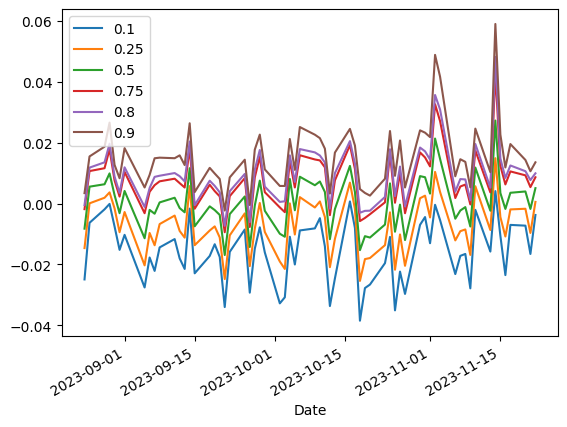

In [85]:
ret_qv_df.plot()

25% stock moved up more than 4%, indicating a strong rally in future

In [156]:
signal = pd.Series([1, 1, 1, 1, 1, 1, 1])
span = 3
mean_signal = ts.ewm(span=span, adjust=True).mean()
alpha = 2 / (span + 1)
norm = pd.Series((1 - (1 - alpha) ** (1 + np.array(range(0, len(ts))))) / alpha, index=ts2.index)
sum_signal = signal * norm

In [158]:
pd.DataFrame([mean_signal, sum_signal], index=["mean", "sum"])

,0,1,2,3,4,5,6
mean,1.0,1.0,1.00,1.000,1.0000,1.00000,1.000000
sum,1.0,1.5,1.75,1.875,1.9375,1.96875,1.984375
